In [1]:
import os
import numpy as np
import open3d as o3d
import pickle
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
img_pkl_path = f"/home/jim/Documents/Projects/GND_alignment/new_AU/AU/AU"
point_cloud_path = f"/home/jim/Documents/Projects/GND_alignment/AU/Scans"
times_txt_path = f"/home/jim/Documents/Projects/GND_alignment/AU/times.txt"

# GMU intrinstic
intrinsic = [[248.621049856283, 0, 333.674701475662],
             [0, 249.443487017099, 174.156912509125],
             [0, 0, 1]]

# GMU extrinsic
extrinsic = [[0, -1, 0, -1.73960485887045],
             [0, 0, -1, -0.547552836129094],
             [1, 0, 0, 0.995256541782342],
             [0, 0, 0, 1]]


In [9]:
for i, (img_dir, lidar_dir) in enumerate(zip(os.listdir(img_pkl_path), os.listdir(point_cloud_path))):
    print(f"extracting {i} out of {len(os.listdir(img_pkl_path))}")
    img_path = os.path.join(img_pkl_path, img_dir)
    lidar_path = os.path.join(point_cloud_path, lidar_dir)
    if os.path.isfile(lidar_path):
        pcd = o3d.io.read_point_cloud(lidar_path)
        pcd_points = np.array(pcd.points)
    else:
        print(f"warning: file {lidar_path} does not exist")
        continue
    if os.path.isfile(img_path):
        with open(img_path, "rb") as f:
            img_data = pickle.load(f)
            img = img_data["camera"]
            pose = img_data["pose"]
            time = img_data["time"]
    else:
        print(f"warning: file {img_path} does not exist")
        continue

    image_size = img[0].shape
    H, W, D = image_size
    depth_image = np.full((H, W), np.inf)

    # Convert point cloud to homogeneous coordinates
    points_hom = np.hstack((pcd_points, np.ones((pcd_points.shape[0], 1))))

    # Transform to camera coordinates
    points_cam = (extrinsic @ points_hom.T).T
    points_cam = points_cam[points_cam[:, 2] > 0]  # Filter points with z > 0

    # print(points_hom)
    raw_pcd = (np.linalg.inv(extrinsic) @ points_cam.T).T

    # Project to image plane
    pixels_hom = (intrinsic @ points_cam[:, :3].T).T
    pixels = pixels_hom[:, :2] / pixels_hom[:, 2:]

    refined_pcd = []
    refined_color = []

    # Rasterize depth image
    for i, (u, v) in enumerate(pixels):
        u, v = int(round(u)), int(round(v))
        if 0 <= u < W and 0 <= v < H:
            z = points_cam[i, 2]
            depth_image[v, u] = min(depth_image[v, u], z)

            refined_pcd.append(raw_pcd[i, :])
            refined_color.append([u, v])

    # Replace inf with 0 (or a desired background value)
    depth_image[depth_image == np.inf] = 0
    refined_pcd = np.array(refined_pcd)[:, :3]
    refined_color = np.array(refined_color)
    # depth_image, np.array(refined_pcd)[:, :3], np.array(refined_color)

    break

extracting 0 out of 1797


In [13]:
pcd_points.shape

(28007, 3)

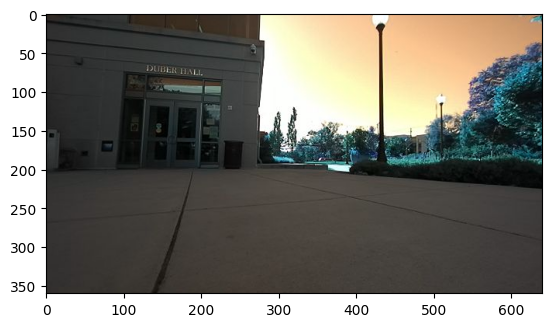

In [7]:
plt.imshow(np.asarray(img[0]))

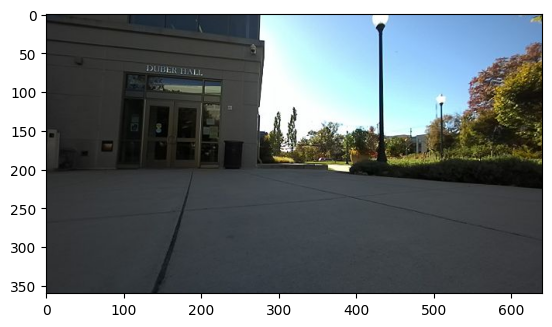

In [14]:
img_convert = cv2.cvtColor(img[0], cv2.COLOR_RGB2BGR)
plt.imshow(img_convert)

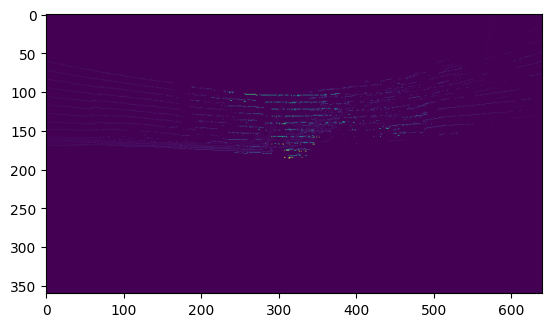

In [8]:
plt.imshow(depth_image)

(array([6.930e+02, 8.860e+02, 8.450e+02, 8.400e+02, 4.690e+02, 1.349e+03,
        2.840e+02, 1.630e+02, 1.920e+02, 1.430e+02, 1.440e+02, 3.550e+02,
        1.570e+02, 1.490e+02, 1.160e+02, 1.100e+02, 6.500e+01, 3.900e+01,
        2.000e+01, 4.900e+01, 5.400e+01, 6.900e+01, 7.100e+01, 6.000e+01,
        2.000e+01, 1.600e+01, 1.000e+01, 8.000e+00, 1.300e+01, 6.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 6.000e+00,
        4.300e+01, 3.400e+01, 3.600e+01, 3.900e+01, 3.600e+01, 4.000e+01,
        1.800e+01, 3.100e+01, 1.900e+01, 1.400e+01, 2.900e+01, 1.100e+01,
        1.000e+01, 9.000e+00, 2.300e+01, 2.000e+00, 2.000e+00, 6.000e+00,
        6.000e+00, 1.700e+01, 2.300e+01, 6.000e+00, 3.000e+00, 4.000e+00,
        2.000e+00, 6.000e+00, 0.000e+00, 1.000e+00, 1.300e+01, 5.000e+00,
        3.000e+00, 4.000e+00, 4.000e+00, 2.000e+00, 0.000e+00, 5.000e+00,
        2.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 3.000e+00, 5.000e+0

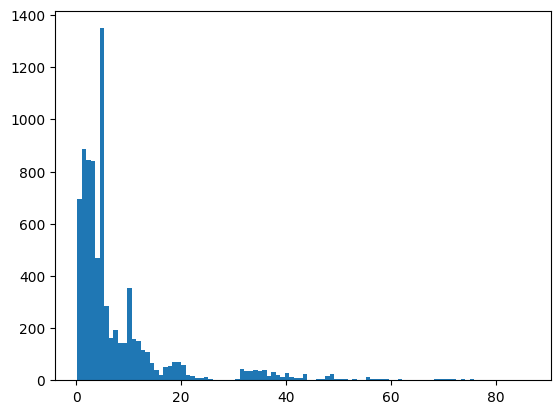

In [43]:
squeezed = depth_image.reshape(-1)
plt.hist(squeezed[squeezed > 0], bins=100)

In [42]:
squeezed[squeezed > 0].shape

(7943,)